# HOMEWORK 1

After the installation of Anaconda, jupyter notebook and the required virtual environment, you will have to test that everything has been set up correctly. For that purpose, you will have to execute the following code and run it without errors.

The code loads an image and creates a picture collage consisting of 4 pictures. Each of the four pictures is a version of the original image with the colour channels swapped.

You will have to also finish some part of the code :-)

In [1]:
import cv2  # Import OpenCV library for computer vision tasks
import numpy as np  # Import NumPy for array and numerical operations
from matplotlib import pyplot as plt  # Import pyplot for plotting images and figures

plt.rcParams['figure.figsize'] = [15, 10]  # Set default figure size for all plots


1418 2048 3


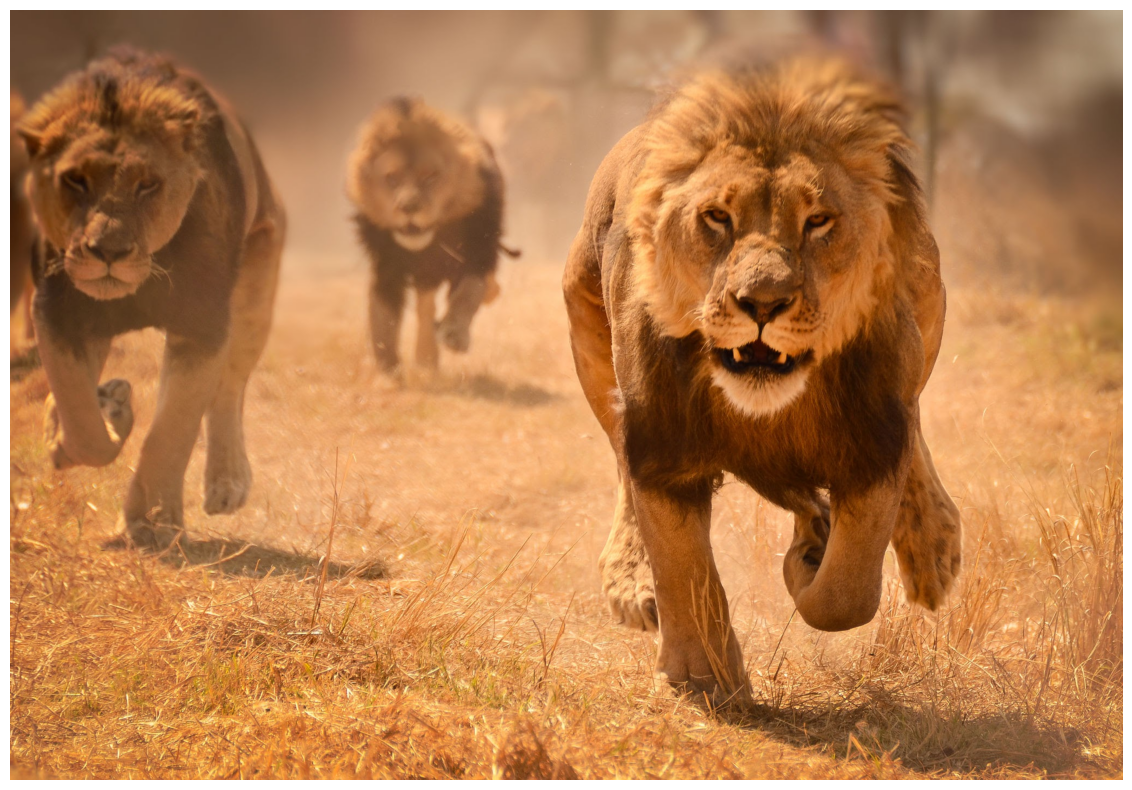

In [2]:
# Load an image. I chose a photo of a lion pride 🦁 that I found on my desktop.
img = cv2.imread('../data/lion.jpg')
img_rgb = None
rows, cols, channels = img.shape  # (1418, 2048, 3) now we know the shape of the image.
print(rows, cols, channels)

# Convert it to RGB

#⭐ VARIANT 1: ~0.6s. Use OpenCV's cvtColor function to convert the image from BGR to RGB color space
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 🌿 it is too easy with example, let's make it a bit more obvious by manually converting it to RGB

#⭐ VARIANT 2: ~0.6s. Manually swap 0th and 2nd channels from BGR to RGB.
img[..., [0,2]] = img[..., [2,0]]

#⭐ VARIANT 3: ~0.6s. # This is a more concise way to swap the channels using slicing.
img = img[:, :, ::-1]



# 🤷‍♂️ I don't really get why we even need to create image filled with zeros and then populate them with the original image again, but let's practice.

#⭐ VARIANT 4: ~4s. Create an empty image and populate it with the original but converted image using list comprehensions
# img_rgb = np.zeros_like(img)
# img_rgb = [[[
#     img[r, c, 2],
#     img[r, c, 1],
#     img[r, c, 0],
# ] for c in range(cols)
# ] for r in range(rows)
# ]

#⭐ VARIANT 5: ~3.5s. do it with a `for` loop
# img_rgb = np.zeros_like(img)  # Create an empty image with the same shape as
# for r in range(rows):
#     for c in range(cols):
#         pixel = img[r, c, :]
#         img_rgb[r, c, 0] = pixel[2]
#         img_rgb[r, c, 1] = pixel[1]
#         img_rgb[r, c, 2] = pixel[0]


if img_rgb is None: img_rgb = img # if we didn't create img_rgb yet (variants 1 to 3), do it now.

# Plot it
plt.axis(False)  # Hide axes for a cleaner display
plt.imshow(img_rgb)  # Plot the image using matplotlib




Let's make a collage.

(np.float64(-0.5), np.float64(4095.5), np.float64(2835.5), np.float64(-0.5))

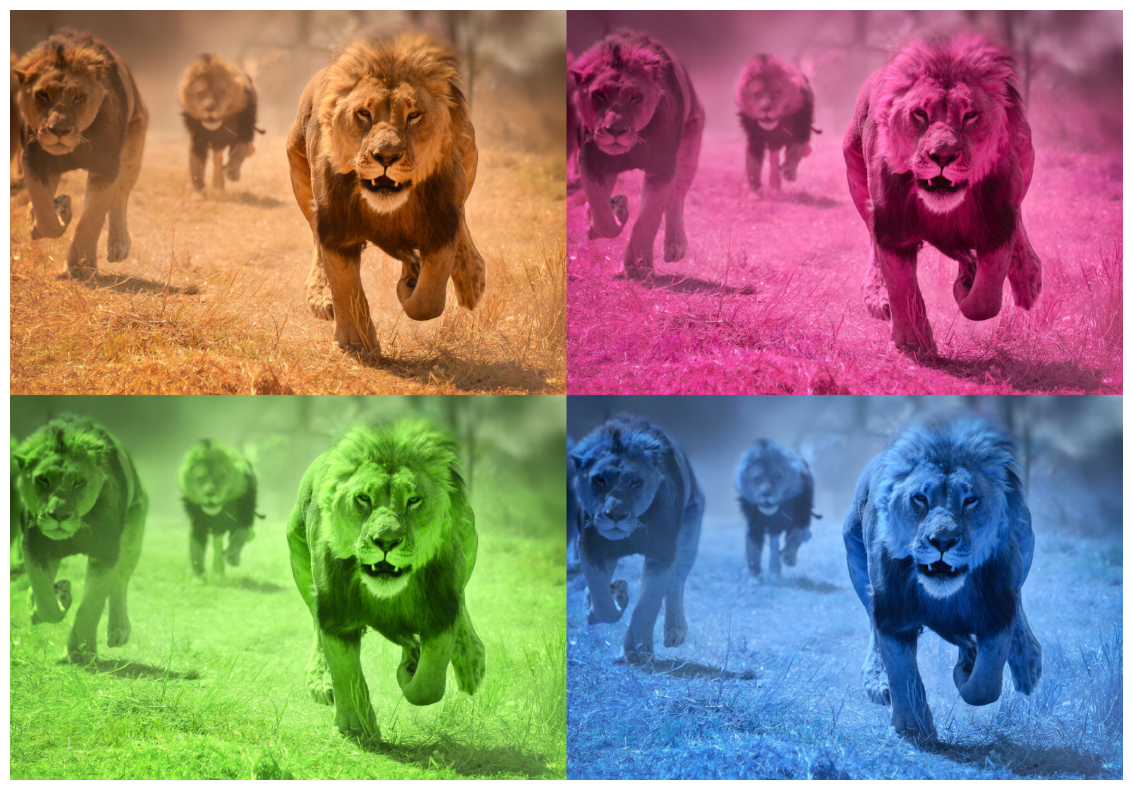

In [6]:
# Split the image into the three colour channels
red, green, blue = cv2.split(img)

# Compose the image in the RGB colour space
img1 = cv2.merge([red, green, blue])

# Compose the image in the RBG colour space
#
img2 = cv2.merge([red, blue, green])

# Compose the image in the GRB colour space
img3 = cv2.merge([green, red, blue])

# Compose the image in the BGR colour space
# ⭐ We can do this in two ways. Since the cv2 library loads images in BGR by default,
# we could simply use the cv2.imread() method. However, if the task requires us to
# "compose" the image, let's follow the same approach as in the examples above.
img4 = cv2.merge([blue, green, red])
# ⭐ img4 = cv2.imread(img)

# Create the collage
out1 = np.hstack([img1, img2])
out2 = np.hstack([img3, img4])
out = np.vstack([out1, out2])

# Plot the collage
plt.imshow(out)
plt.axis(False)

And now you are going to make a simple geometric collage. You need to flip your image both horizontally and vertically to obtain the following result.

![alt text](../data/example.jpg "Title")

You can flip the images "manually" but you might also find useful the numpy functions [fliplr](https://numpy.org/doc/stable/reference/generated/numpy.fliplr.html) and [flipud](https://numpy.org/doc/stable/reference/generated/numpy.flipud.html) ;-).

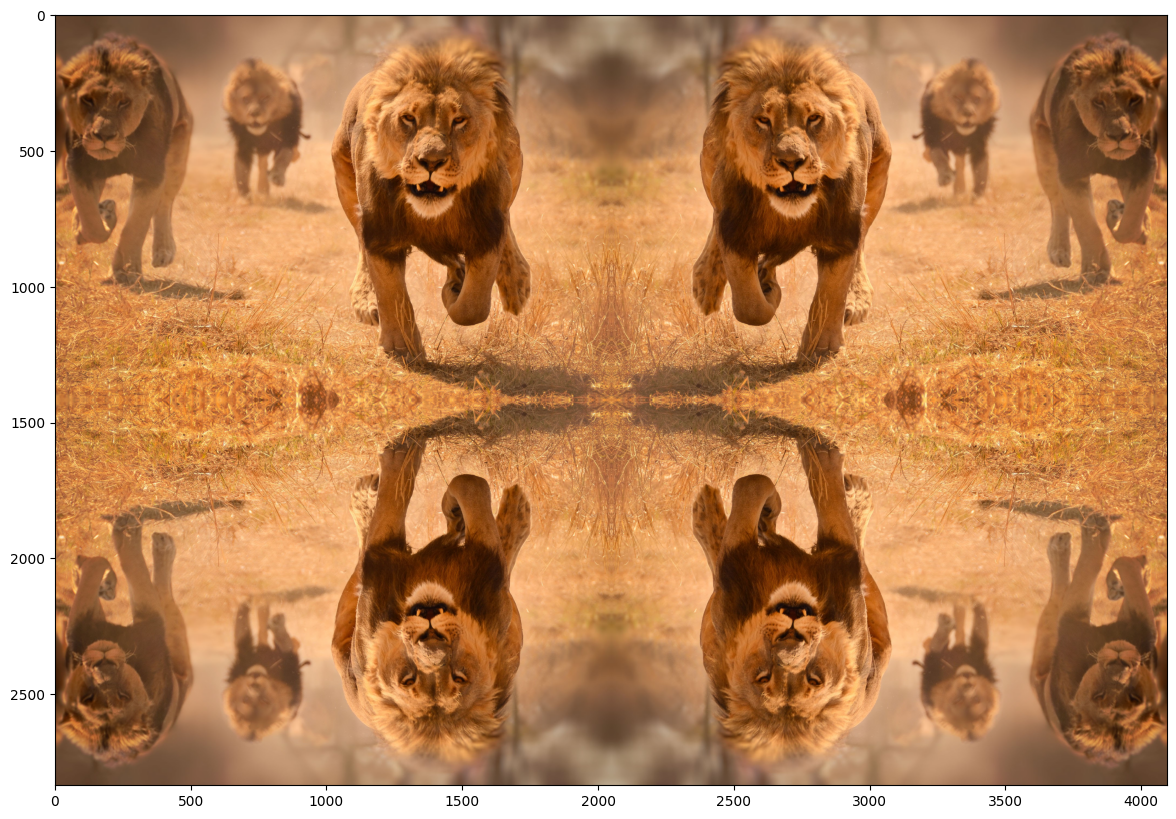

In [5]:
# Load an image (you can freely chose any image you like)
img = cv2.imread('../data/lion.jpg')
# Convert it to RGB
img[..., [0,2]] = img[..., [2,0]]  # Swap the first and third channels to convert BGR to RGB

# Make a collage
img2 = np.fliplr(img)
img3 = np.flipud(img)
img4 = np.flipud(img2)

out1 = np.hstack([img1, img2])
out2 = np.hstack([img3, img4])
out = np.vstack([out1, out2])

# Plot the collage
plt.imshow(out)